<div align="center">
    <font color="0F5298" size="7">
        Deep Learning <br>
    </font>
    <font color="2565AE" size="5">
        CE Department <br>
        Spring 2024 - Prof. Soleymani Baghshah <br>
    </font>
    <font color="3C99D" size="5">
        HW2 Practical <br>
    </font>
    <font color="696880" size="5">
        40 Points
    </font>
</div>


You'll be building your own U-Net, a type of CNN designed for quick, precise image segmentation, and using it to predict a label for every single pixel in an image - in this case, an image from a self-driving car dataset.

This type of image classification is called semantic image segmentation. It's similar to object detection in that both ask the question: "What objects are in this image and where in the image are those objects located?," but where object detection labels objects with bounding boxes that may include pixels that aren't part of the object, semantic image segmentation allows you to predict a precise mask for each object in the image by labeling each pixel in the image with its corresponding class. The word “semantic” here refers to what's being shown, so for example the “Car” class is indicated below by the dark blue mask, and "Person" is indicated with a red mask:


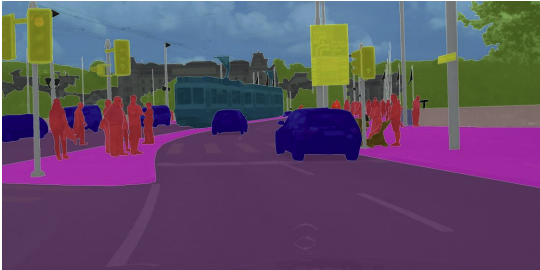 <br>
<u><b>Figure 1</u></b>: Example of a segmented image <br>

As you might imagine, region-specific labeling is a pretty crucial consideration for self-driving cars, which require a pixel-perfect understanding of their environment so they can change lanes and avoid other cars, or any number of traffic obstacles that can put peoples' lives in danger.

By the time you finish this notebook, you'll be able to:

* Build your own U-Net
* Explain the difference between a regular CNN and a U-net
* Implement semantic image segmentation on the CARLA self-driving car dataset
* Apply sparse categorical crossentropy for pixelwise prediction

Onward, to this grand and glorious quest!

## Downloading Dataset

> **Note:**  
> The instructor originally provided the dataset through Google Drive, but unfortunately it is no longer available.  
> To keep this notebook fully reproducible, I replaced it with the similar [`CamVid`](https://www.kaggle.com/datasets/carlolepelaars/camvid) dataset from Kaggle.  
> The following cells show how to authenticate with Kaggle and download the dataset.
>
> **For users in Iran 🇮🇷** (like me): Unfortunately😥, you'll need a VPN to download datasets from Kaggle.

In [ ]:
import kagglehub

kagglehub.login()

In [ ]:
import kagglehub

print(kagglehub.whoami())

In [ ]:
# Download latest version
path = kagglehub.dataset_download("carlolepelaars/camvid")

print("Path to dataset files:", path)

<a name='1'></a>
## 1 - Packages

Run the cell below to import all the libraries you'll need:

In [ ]:
# pip install imageio

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchsummary import summary
from torchvision import transforms, io
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import pandas as pd
import imageio
import matplotlib.pyplot as plt


### Chack if GPU is available

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<a name='2'></a>
## 2 - Load the Data

In [3]:
from pathlib import Path

root = Path(
    "E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data/camvid"
)

In [4]:
for item in root.iterdir():
    print(item.name)

class_dict.csv
test
test_labels
train
train_labels
val
val_labels


In [5]:
root

WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data/camvid')

In [6]:
image_path = root / "train" 
mask_path = root / "train_labels" 

In [7]:
image_list = list(image_path.iterdir())
mask_list  = list(mask_path.iterdir())

In [8]:
image_list

[WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data/camvid/train/0001TP_009210.png'),
 WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data/camvid/train/0001TP_009240.png'),
 WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data/camvid/train/0001TP_009390.png'),
 WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data/camvid/train/0001TP_009420.png'),
 WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data/camvid/train/0001TP_009450.png'),
 WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/data/camvid/train/0001TP_009480.png'),
 WindowsPath('E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2

>**Note:**
>in the camvid dataset, the training and validation dataset are seperate from each other *(opposite of the instructor dataset)*, so in the following cells, we are gonna concat them into Image_dataset

### Check out the some of the unmasked and masked images from the dataset:

After you are done exploring, revert back to `N=2`. Otherwise the autograder will throw a `list index out of range` error.

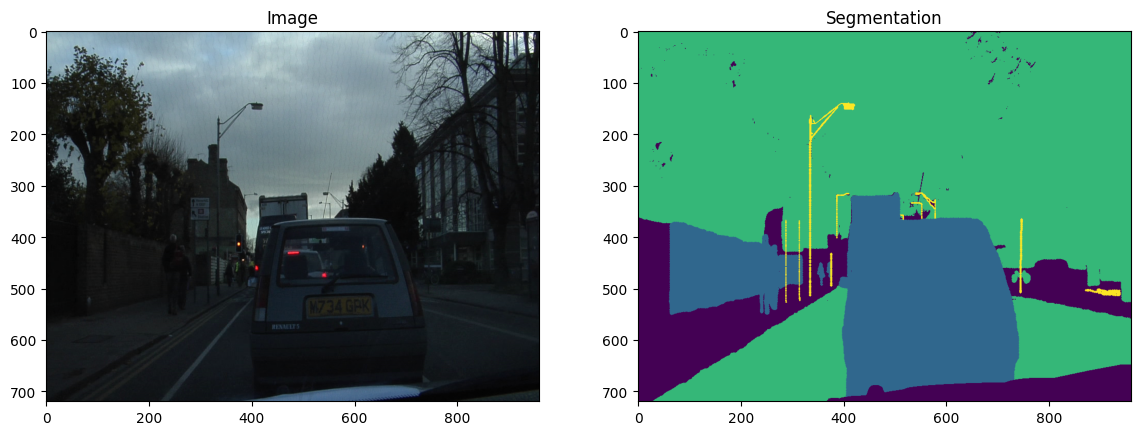

In [9]:
import imageio.v2 as imageio
N = 2
img = imageio.imread(image_list[N])
mask = imageio.imread(mask_list[N])

fig, arr = plt.subplots(1, 2, figsize=(14, 10))
arr[0].imshow(img)
arr[0].set_title('Image')
arr[1].imshow(mask[:, :, 0])
arr[1].set_title('Segmentation')
plt.show()

and another one

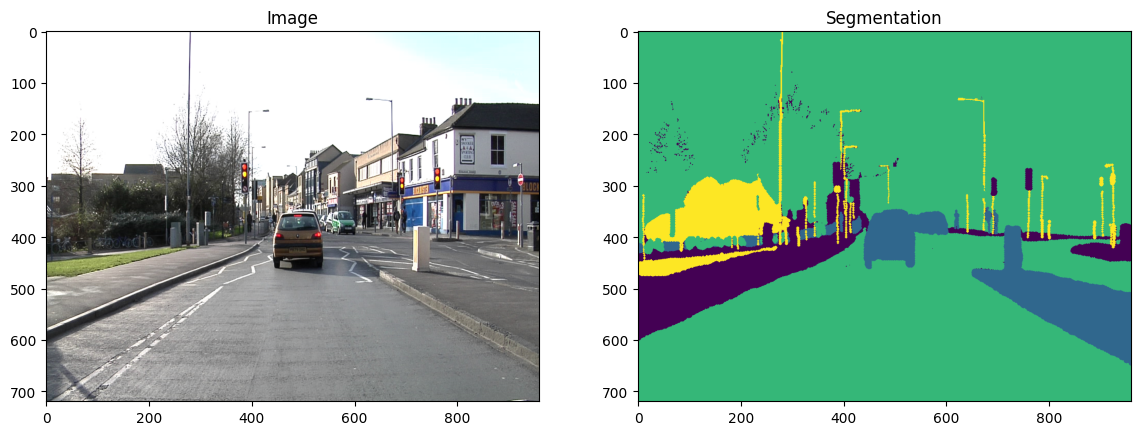

In [10]:
import imageio.v2 as imageio
N = 100
img = imageio.imread(image_list[N])
mask = imageio.imread(mask_list[N])

fig, arr = plt.subplots(1, 2, figsize=(14, 10))
arr[0].imshow(img)
arr[0].set_title('Image')
arr[1].imshow(mask[:, :, 0])
arr[1].set_title('Segmentation')
plt.show()

<a name='2-2'></a>
### 2.2 - Preprocess Your Data



In [11]:
def rgb_to_class_index(mask, color_map):
    """
    Convert an RGB segmentation mask from [3, H, W]
    to a class-index mask of shape [H, W]. Note that we still use colors (RGB) to show classes for each pixel,
    but now we have a total of 32 colors (len(color_map)) for each pixel to choose model between them, 
    intead of 256**3
    """

    mask = mask.permute(1, 2, 0)  # [H, W, 3]

    class_mask = torch.full(
        mask.shape[:2],         # [H, W]
        fill_value=-1,          # no class (yet)
        dtype=torch.long        # type convert to int64 for CrossEntropyLoss
    )

    for class_id, color in enumerate(color_map):
        color = torch.tensor(
            color,
            dtype=mask.dtype,
            device=mask.device
        )

        matches = torch.all(mask == color, dim=-1)  # getting exactly similar pixel colors
        class_mask[matches] = class_id

    if (class_mask == -1).any():
        unknown_pixels = (class_mask == -1).sum().item()

        raise ValueError(
            f"{unknown_pixels} pixels do not match any color "
            "defined in color_map."
        )

    return class_mask

In [12]:
import pandas as pd
class_df = pd.read_csv(root / "class_dict.csv")
class_df.head()

,name,r,g,b
0,Animal,64,128,64
1,Archway,192,0,128
2,Bicyclist,0,128,192
3,Bridge,0,128,64
4,Building,128,0,0


In [13]:
color_map = [
    (row["r"], row["g"], row["b"])
    for _, row in class_df.iterrows()
]
color_map

[(64, 128, 64),
 (192, 0, 128),
 (0, 128, 192),
 (0, 128, 64),
 (128, 0, 0),
 (64, 0, 128),
 (64, 0, 192),
 (192, 128, 64),
 (192, 192, 128),
 (64, 64, 128),
 (128, 0, 192),
 (192, 0, 64),
 (128, 128, 64),
 (192, 0, 192),
 (128, 64, 64),
 (64, 192, 128),
 (64, 64, 0),
 (128, 64, 128),
 (128, 128, 192),
 (0, 0, 192),
 (192, 128, 128),
 (128, 128, 128),
 (64, 128, 192),
 (0, 0, 64),
 (0, 64, 64),
 (192, 64, 128),
 (128, 128, 0),
 (192, 128, 192),
 (64, 0, 64),
 (192, 192, 0),
 (0, 0, 0),
 (64, 192, 0)]

In [14]:
class Segmentation_Dataset(Dataset):
    def __init__(
        self,
        ImagesDirectory,
        MasksDirectory,
        color_map
    ):
        self.ImagesDirectory = ImagesDirectory
        self.MasksDirectory = MasksDirectory
        self.color_map = color_map

        self.images = sorted(os.listdir(self.ImagesDirectory))

        self.mask_transforms = transforms.Compose([
            transforms.Resize(
                (192, 256),
                interpolation=transforms.InterpolationMode.NEAREST
            )
        ])

        self.image_transforms = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(
                (192, 256),
                interpolation=transforms.InterpolationMode.BILINEAR
            ),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x[:3])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_name = self.images[index]

        img_path = os.path.join(
            self.ImagesDirectory,
            img_name
        )

        img = io.read_file(str(img_path))
        img = io.decode_png(img)

        mask_name = img_name.replace(".png", "_L.png")     

        mask_path = os.path.join(
            self.MasksDirectory,
            mask_name
        )

        # [3, H, W]
        mask = io.read_image(str(mask_path))[:3]

        # Resize RGB mask before converting colors to class IDs
        mask = self.mask_transforms(mask)

        # [3, H, W] -> [H, W]
        mask = rgb_to_class_index(
            mask,
            color_map=self.color_map
        )

        img = self.image_transforms(img)

        return {
            "IMAGE": img,
            "MASK": mask
        }

> **Note:**  
> In the previous cell, we used the RGB color values provided in the CamVid dataset's `class_dict.csv` file to convert each pixel into its corresponding class index.
>
> **Why is this necessary?**
>
> The original implementation reduced the RGB mask to a single channel using:
>
> ```python
> mask, _ = torch.max(mask[:3], dim=0, keepdim=True)
> ```
>
> While this approach may have been suitable for the instructor's original dataset, it is **not compatible with CamVid**. CamVid encodes each semantic class using a unique RGB color, so reducing the RGB channels with `torch.max()` destroys the class information.
>
> For example, the following two different classes would both be reduced to the same value:
>
> ```text
> [128,  64, 128] → 128
> [128, 128, 128] → 128
> ```
>
> Although these colors represent **different semantic classes**, they would incorrectly become the same label after applying `torch.max()`. Therefore, we convert each RGB color to its corresponding class index before training, which is the format expected by `nn.CrossEntropyLoss()`.

>**Note**:
>in
>```python
>interpolation=transforms.InterpolationMode.NEAREST
>```
>a better function to interpolate the images are `BILINEAR` 
>
>beside that i changed a little of the code in line 
>```python
>mask_path = os.path.join(self.MasksDirectory, img_name)
>```
>**into** 
>```python
>mask_name = img_name.replace(".png", "_L.png")
>
>mask_path = os.path.join(
>    self.MasksDirectory,
>    mask_name
>)
>```  
>
> because in the camvid dataset, all the label pictures, has **_L** as the postfix

<a name='2-3'></a>
### 2.3 - Hyper-parameters and Optimizer

In [15]:
EPOCHS = 50
BATCH_SIZE = 8
LR = 1e-3       # for adam
B1 = 0.9        # for adam
B2 = 0.999      # for adam

<a name='3'></a>
## 3 - U-Net

U-Net, named for its U-shape, was originally created in 2015 for tumor detection, but in the years since has become a very popular choice for other semantic segmentation tasks.

U-Net builds on a previous architecture called the Fully Convolutional Network, or FCN, which replaces the dense layers found in a typical CNN with a transposed convolution layer that upsamples the feature map back to the size of the original input image, while preserving the spatial information. This is necessary because the dense layers destroy spatial information **(the "where" of the image)**, which is an essential part of image segmentation tasks. An added bonus of using transpose convolutions is that the input size no longer needs to be fixed, as it does when dense layers are used.

Unfortunately, the final feature layer of the FCN suffers from information loss due to downsampling too much. It then becomes difficult to upsample after so much information has been lost, causing an output that looks rough.

U-Net improves on the FCN, using a somewhat similar design, but differing in some important ways.  Instead of one transposed convolution at the end of the network, it uses a matching number of convolutions for downsampling the input image to a feature map, and transposed convolutions for upsampling those maps back up to the original input image size. It also adds skip connections, to retain information that would otherwise become lost during encoding. Skip connections send information to every upsampling layer in the decoder from the corresponding downsampling layer in the encoder, capturing finer information while also keeping computation low. These help prevent information loss, as well as model overfitting.

<a name='3-1'></a>
### 3.1 - Model Details

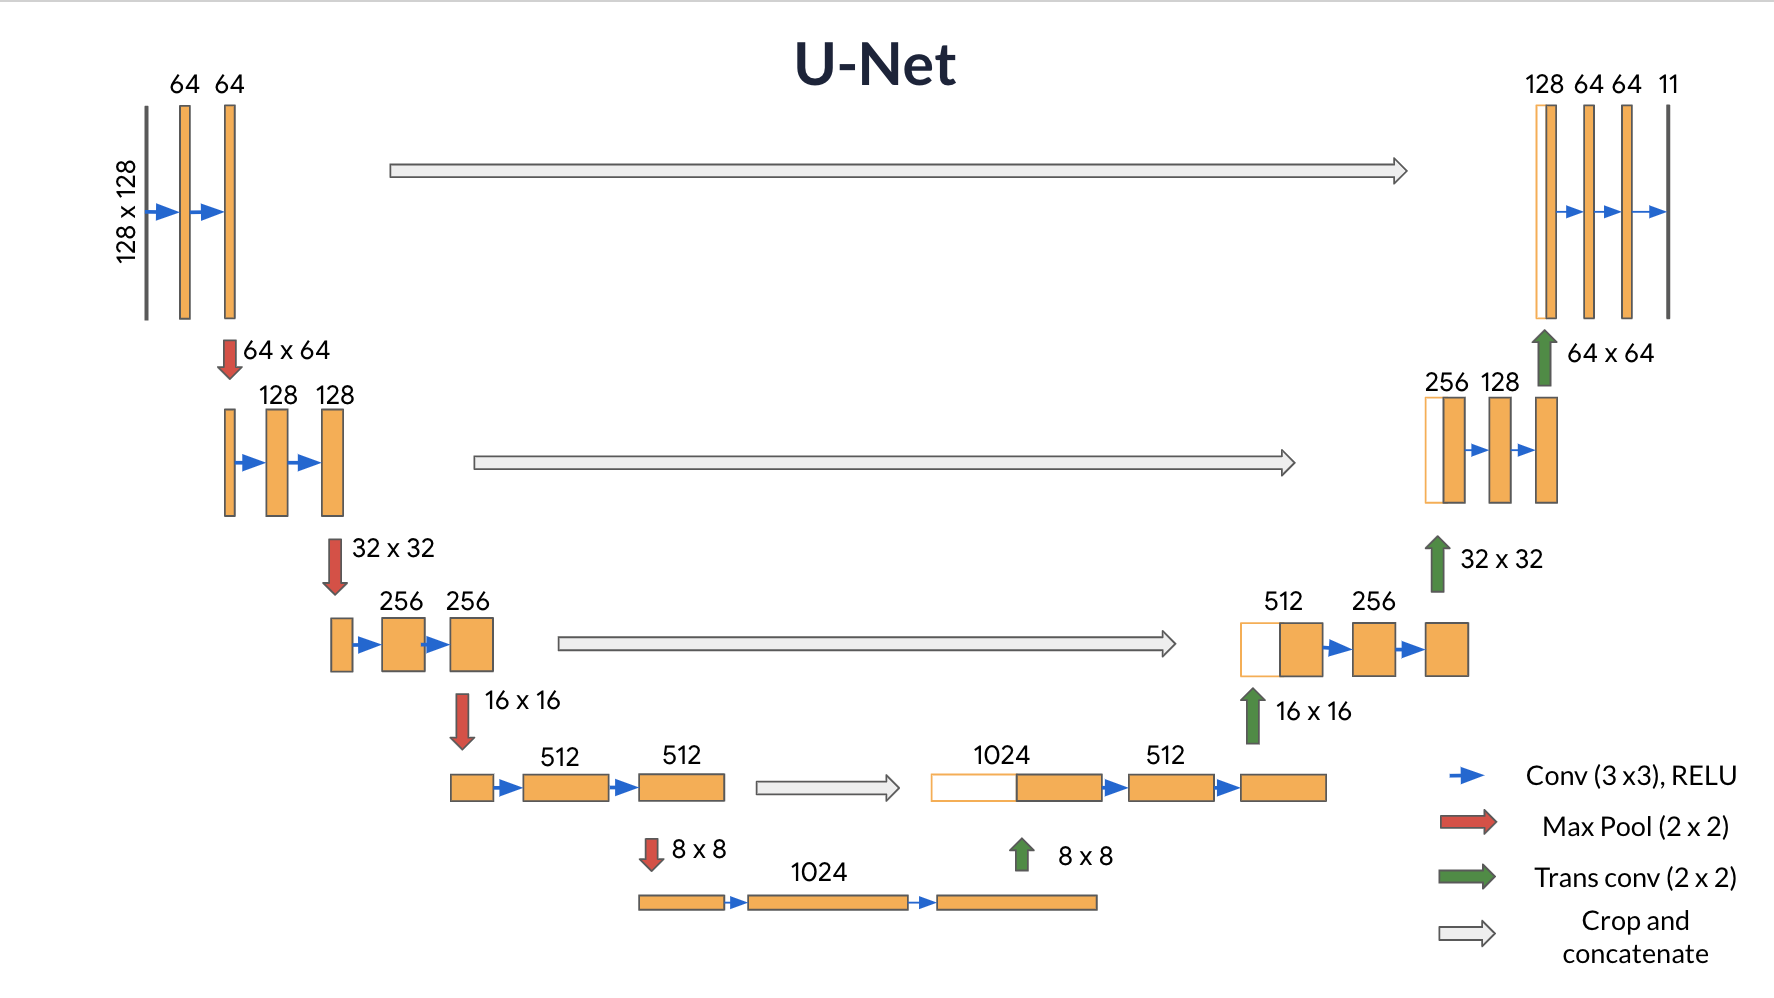<br>
<u><b> Figure 2 </u></b>: U-Net Architecture<br>

**Contracting path** (Encoder containing downsampling steps):

Images are first fed through several convolutional layers which reduce height and width, while growing the number of channels.

The contracting path follows a regular CNN architecture, with convolutional layers, their activations, and pooling layers to downsample the image and extract its features. In detail, it consists of the repeated application of two 3 x 3 valid padding convolutions, each followed by a rectified linear unit (ReLU) and a 2 x 2 max pooling operation with stride 2 for downsampling. At each downsampling step, the number of feature channels is doubled.

**Crop function**: This step crops the image from the contracting path and concatenates it to the current image on the expanding path to create a skip connection.

**Expanding path** (Decoder containing upsampling steps):

The expanding path performs the opposite operation of the contracting path, growing the image back to its original size, while shrinking the channels gradually.

In detail, each step in the expanding path upsamples the feature map, followed by a 2 x 2 convolution (the transposed convolution). This transposed convolution halves the number of feature channels, while growing the height and width of the image.

Next is a concatenation with the correspondingly cropped feature map from the contracting path, and two 3 x 3 convolutions, each followed by a ReLU. You need to perform cropping to handle the loss of border pixels in every convolution.

**Final Feature Mapping Block**: In the final layer, a 1x1 convolution is used to map each 64-component feature vector to the desired number of classes. The channel dimensions from the previous layer correspond to the number of filters used, so when you use 1x1 convolutions, you can transform that dimension by choosing an appropriate number of 1x1 filters. When this idea is applied to the last layer, you can reduce the channel dimensions to have one layer per class.

The U-Net network has 23 convolutional layers in total.

#### Important Note:
The figures shown in the assignment for the U-Net architecture depict the layer dimensions and filter sizes as per the original paper on U-Net with smaller images. However, due to computational constraints for this assignment, you will code only half of those filters. The purpose of showing you the original dimensions is to give you the flavour of the original U-Net architecture. The important takeaway is that you multiply by 2 the number of filters used in the previous step. The notebook includes all of the necessary instructions and hints to help you code the U-Net architecture needed for this assignment.

>**Note**:<br>
>in the dataset we downloaded previously, we have a number of classes in total of 33, so we should have 33 channels in the final layer<br>
>Max Pooling with **Stride = 2** and **padding =1**

<a name='3-2'></a>
### 3.2 - Convolution Blocks
In both the encoder and the decoder, we see repeated applications of 2D convolution blocks, each followed by ReLU activation. In the following cell, you'll implement these building blocks.

In [16]:
import torch.nn as nn

class Block(nn.Module):

    def __init__(self, in_ch, out_ch):
        """
        Initializes the Block with the specified input and output channels.

        Args:
            in_ch (int): Number of input channels.
            out_ch (int): Number of output channels.
        """
        super().__init__()

        # TODO:
        #    Create a list of layers that includes:
        #    - A 2D convolutional layer with in_ch input channels and out_ch
        #      output channels, using a kernel size of 3 and 'same' padding.
        #    - A ReLU activation function.
        #    - A second 2D convolutional layer with out_ch input and output
        #      channels, using a kernel size of 3 and 'same' padding.
        #    - A second ReLU activation function.

        layers = [
            nn.Conv2d(
                in_ch, out_ch, kernel_size=(3,3), padding='same'
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_ch, out_ch, kernel_size=(3,3), padding='same'
            ),
            nn.ReLU(inplace=True)
        ]

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass through the convolutional block.

        Args:
            x (torch.Tensor): Input tensor of shape (N, in_ch, H, W), where N is the batch size,
                              H is the height, and W is the width.

        Returns:
            torch.Tensor: Output tensor of shape (N, out_ch, H, W).
        """
        return self.conv(x)



In [17]:
# test your implementation
enc_block = Block(1, 64)
x         = torch.randn(1, 1, 128, 128) # 1 picture (or batch size of 8) of 1 channel 128 x 128
enc_block(x).shape

torch.Size([1, 64, 128, 128])

<a name='3-2'></a>
### 3.3- Encoder (Downsampling Block)

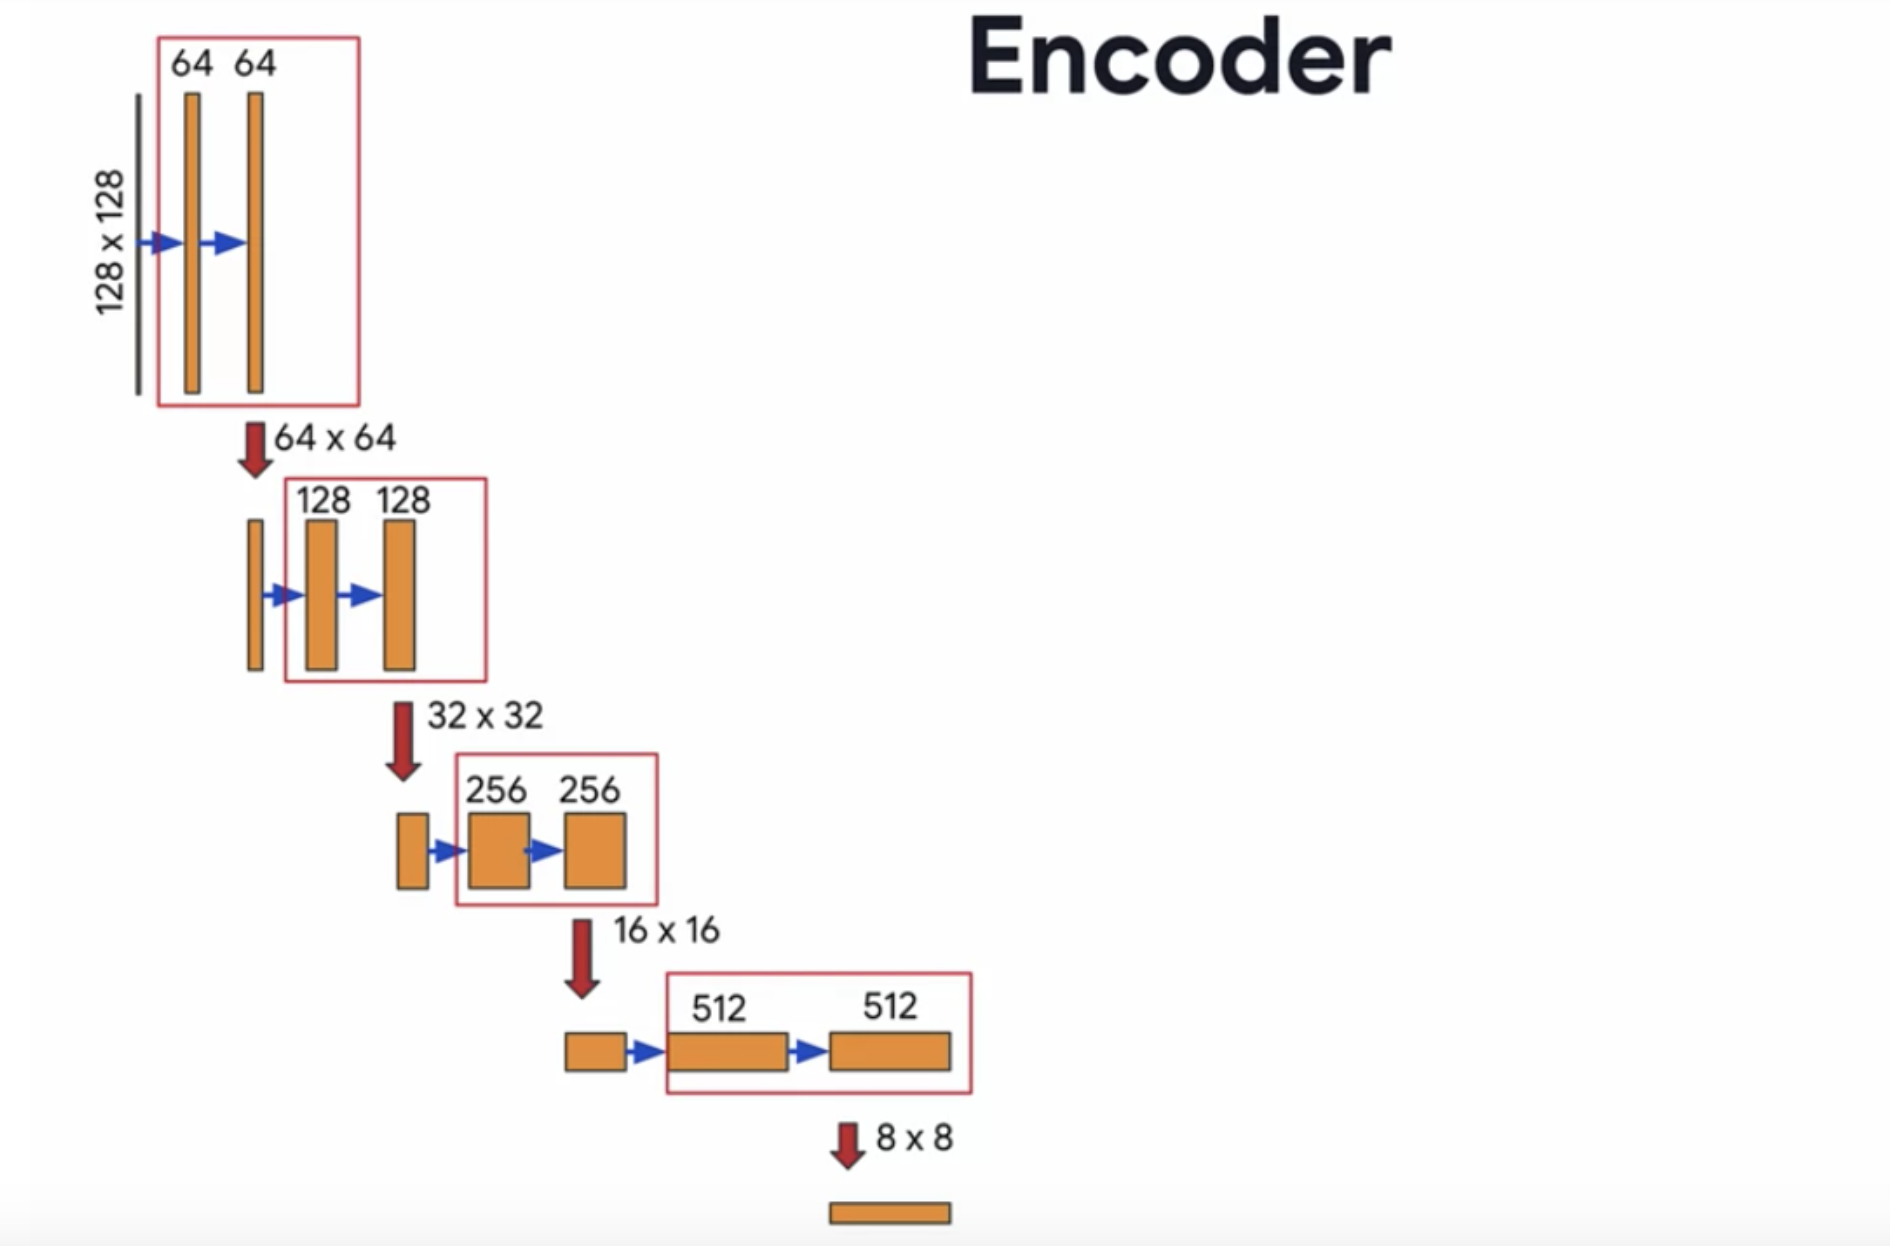<br>
<u><b>Figure 3</u></b>: The U-Net Encoder up close <br>

<a name='3-2'></a>
### 3.3 - Encoder (Downsampling Block)

So far we have implemented the convolution operations but not the downsampling part. The contractive path consists of the repeated application of two 3x3 convolutions, each followed by a rectified linear unit (ReLU) and a 2x2 max pooling operation with stride 2 for downsampling. At each downsampling step we double the number of feature channels.

We now need to add max pooling after each block to compose a list of downsampling blocks. Note that, we need to store the output of convolutional blocks before the application of max pooling. The output of convolutional blocks will be later used in the expansive path.

In [18]:
import torch.nn as nn

class Encoder(nn.Module):


    def __init__(self, chs=(3, 64, 128, 256, 512, 1024)):
        """
        Initializes the Encoder with the specified channel sizes.

        Args:
            chs (tuple): A tuple containing the number of channels for each
            layer in the encoder.
        """
        super().__init__()

        # TODO:
        #    Create a list of downsampling blocks using the Block class.
        #    - Use a ModuleList to store the blocks.    
        #    - Each block should take the number of input channels from chs[i]
        #      and output channels from chs[i+1].

        self.enc_blocks = nn.ModuleList()

        for channel in range(len(chs)-1):
            self.enc_blocks.append(Block(chs[channel] , chs[channel + 1]))

        # TODO:
        #    Initialize a max pooling layer with a kernel size of 2 and stride
        #    of 2 for downsampling.

        self.pool = nn.MaxPool2d(2,2)

    def forward(self, x):
        """
        Forward pass through the encoder.

        Args:
            x (torch.Tensor): Input tensor of shape (N, C, H, W), where N is
            the batch size, C is the number of input channels, H is the height,
            and W is the width.

        Returns:
            list: A list of feature maps from each downsampling block.
        """
        ftrs = []

        # TODO:
        #    Iterate through each block in enc_blocks:
        #    - Pass the input tensor x through the block.
        #    - Append the output feature map to the ftrs list.
        #    - Apply the max pooling operation to downsample the feature map.
        for block in self.enc_blocks:
            x = block(x)
            ftrs.append(x)
            x = self.pool(x)
            
        return ftrs


In [19]:
# test your implementation
encoder = Encoder()
# input image
x    = torch.randn(1, 3, 128, 128)
ftrs = encoder(x)
for ftr in ftrs: print(ftr.shape)

torch.Size([1, 64, 128, 128])
torch.Size([1, 128, 64, 64])
torch.Size([1, 256, 32, 32])
torch.Size([1, 512, 16, 16])
torch.Size([1, 1024, 8, 8])


<a name='3-3'></a>
### 3.4 - Decoder (Upsampling Block)

The decoder, or upsampling block, upsamples the features back to the original image size. At each upsampling level, you'll take the output of the corresponding encoder block and concatenate it before feeding to the next decoder block.

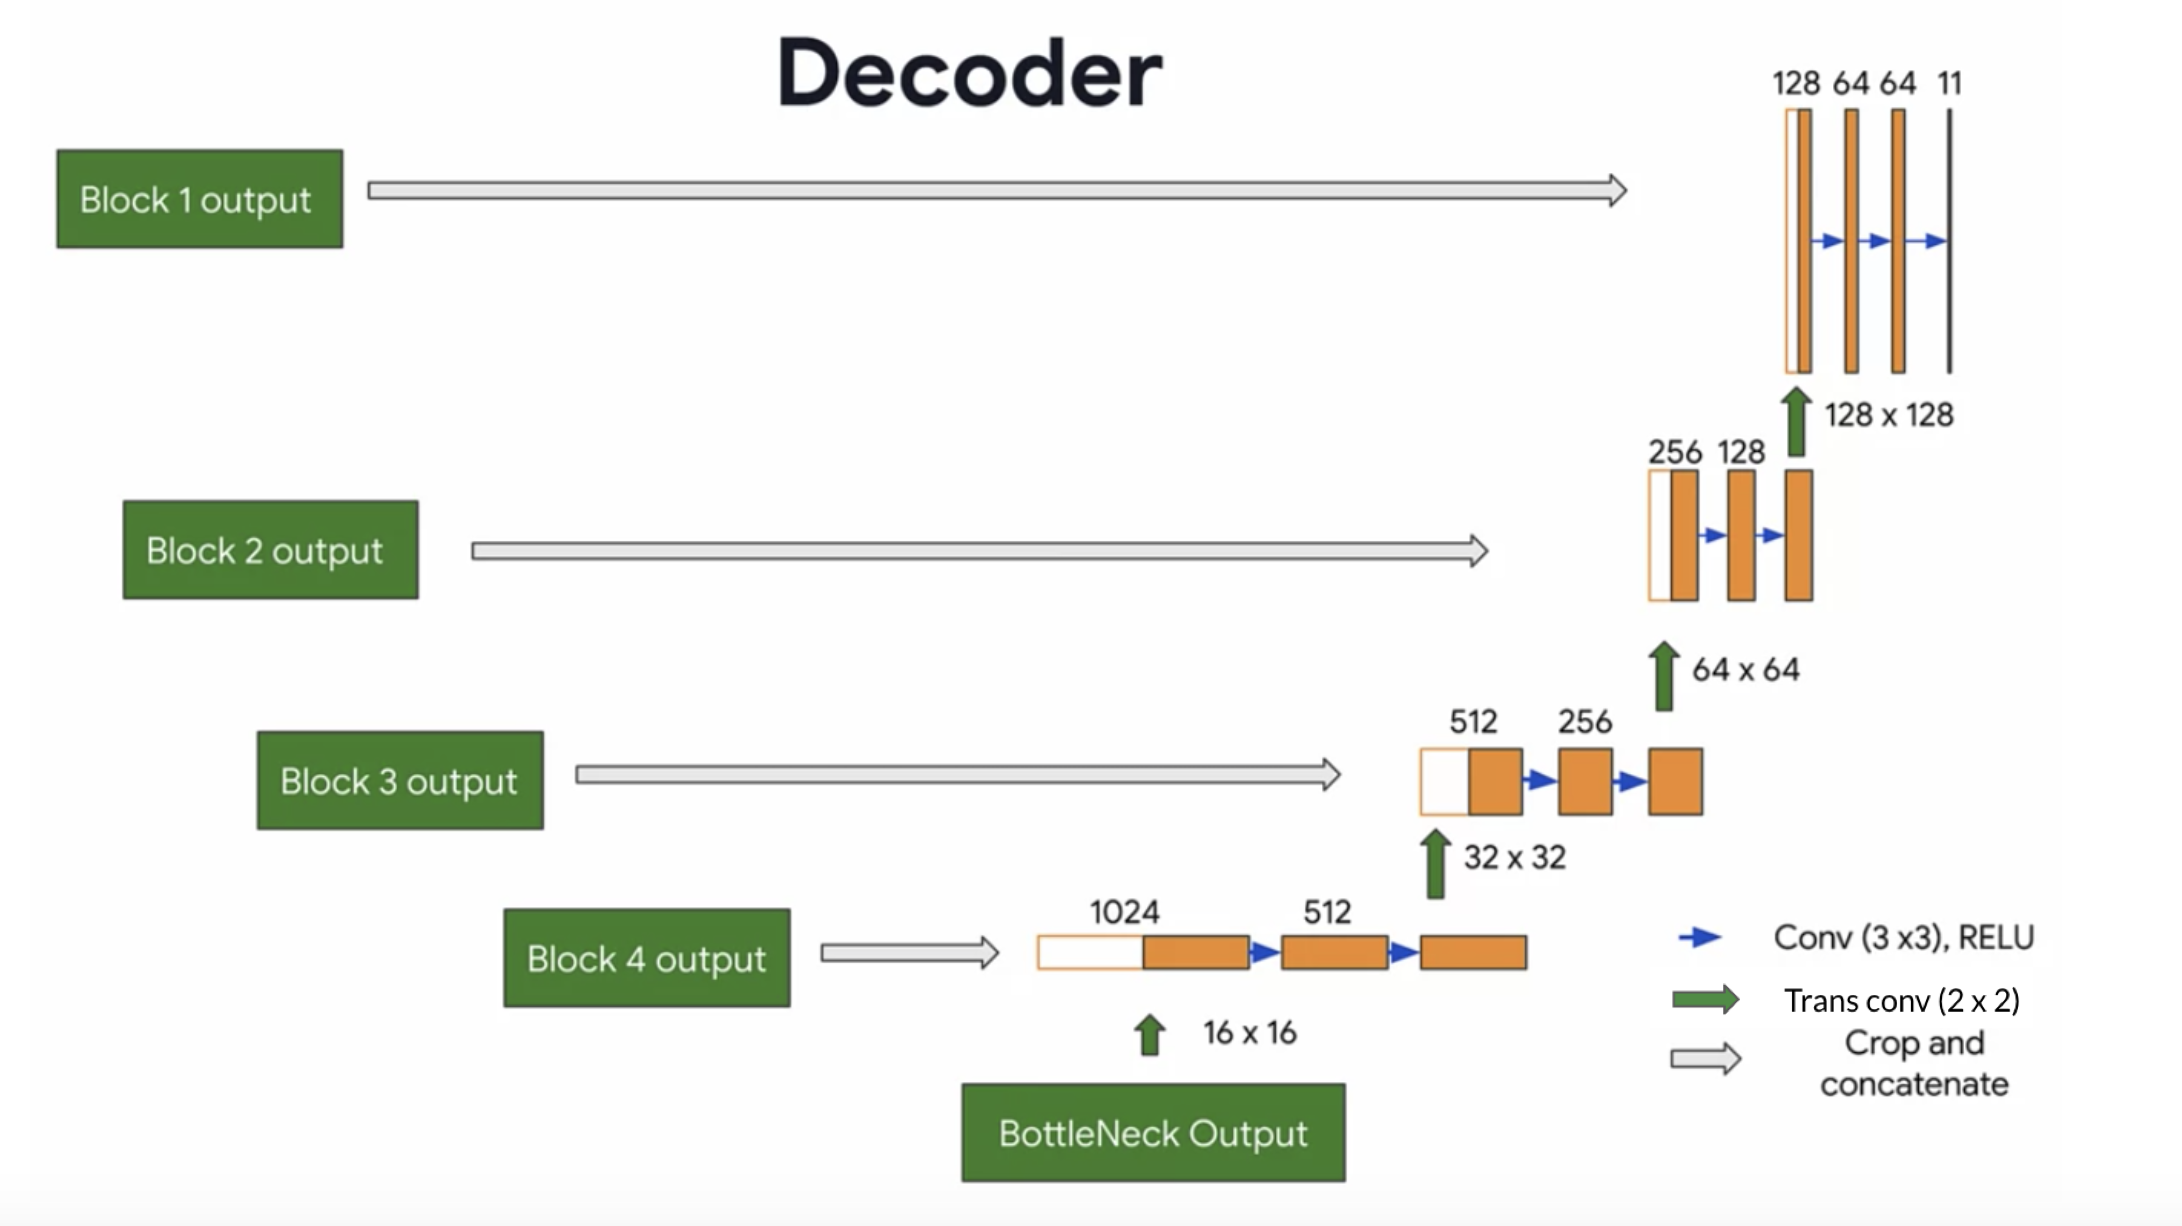<br>
<u><b>Figure 4</u></b>: The U-Net Decoder up close <br>

The Decoder, is the expansive path of the U-Net Architecture.

Every step in the expansive path consists of an upsampling of the feature map followed by a 2x2 convolution (“up-convolution”) that halves the number of feature channels, a concatenation with the feature map from the contracting path, and two 3x3 convolutions, each followed by a ReLU.

Note that we have already implemented the part where two 3x3 convolutions occur followed by ReLU activation in Block. All we need to do to implement the Decoder is to add the “up-convolution” and the feature concatenation.

Note that in PyTorch, the ConvTranspose2d operation performs the “up-convolution”. It accepts parameters like in_channels, out_channels, kernel_size and stride amongst others.

In [20]:
x

tensor([[[[ 1.1681, -0.3237, -0.2182,  ...,  0.7117, -0.6605,  0.7596],
          [ 1.8696, -0.1128,  0.7851,  ..., -0.1422, -0.4682,  0.6259],
          [-1.4732, -1.0364,  1.1660,  ...,  0.7685,  1.5196,  0.3170],
          ...,
          [ 1.3299,  0.1654, -0.2356,  ..., -0.0252,  0.1944, -0.1476],
          [ 0.5998, -1.4960, -0.4368,  ..., -0.5411,  0.2955,  0.6201],
          [-0.0534,  1.4345, -0.3746,  ..., -0.7885,  0.3177, -0.1809]],

         [[ 0.9635, -0.4632,  0.3792,  ..., -0.4242,  0.1143, -0.4760],
          [ 0.7843, -1.4400, -0.8945,  ..., -0.6518,  0.9588, -0.5635],
          [-0.2924,  0.2985, -0.3053,  ..., -0.8715,  0.1998, -0.3175],
          ...,
          [ 0.2627, -0.6807,  0.3164,  ..., -0.4698,  1.2535, -0.3882],
          [ 1.6168,  0.5390,  0.7371,  ..., -0.8641, -1.3720, -0.3766],
          [-0.9829, -0.0705, -0.8268,  ..., -1.5915, -1.3173,  0.0199]],

         [[-1.5745, -0.2460,  1.5045,  ..., -0.6950, -0.6402, -0.4377],
          [-0.0500,  1.1917,  

In [22]:
class Decoder(nn.Module):

    def __init__(self, chs=(1024, 512, 256, 128, 64)):
        super().__init__()

        self.upconvs = nn.ModuleList()
        self.dec_blocks = nn.ModuleList()

        for i in range(len(chs) - 1):

            self.upconvs.append(
                nn.ConvTranspose2d(
                    in_channels=chs[i],
                    out_channels=chs[i + 1],
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            )

            self.dec_blocks.append(
                Block(
                    in_ch=chs[i],
                    out_ch=chs[i + 1]
                )
            )

    def forward(self, x, enc_ftrs):

        for i in range(len(self.upconvs)):

            x = self.upconvs[i](x)

            skip = enc_ftrs[i]

            x = torch.cat((x, skip), dim=1)

            x = self.dec_blocks[i](x)

        return x

In [23]:
# test your implementation
decoder = Decoder()
decoder(ftrs[::-1][0], ftrs[::-1][1:]).shape

torch.Size([1, 64, 128, 128])

<a name='3-4'></a>
### 3.4 - Build the Model

This is where you'll put it all together, by chaining the encoder, bottleneck, and decoder! You'll need to specify the number of output channels, which for this particular set would be 23. That's because there are 23 possible labels for each pixel in this self-driving car dataset.

In [24]:
import torch.nn as nn

class UNet(nn.Module):


    def __init__(self, enc_chs=(3, 64, 128, 256, 512, 1024), dec_chs=(1024, 512, 256, 128, 64), num_class=2):
        """
        Initializes the U-Net with the specified channel sizes and number of classes.

        Args:
            enc_chs (tuple): A tuple containing the number of channels for each layer in the encoder.
            dec_chs (tuple): A tuple containing the number of channels for each layer in the decoder.
            num_class (int): The number of output classes for segmentation.
        """
        super().__init__()
        self.encoder = Encoder(enc_chs)
        self.decoder = Decoder(dec_chs)

        # TODO:
        #    Initialize the final convolutional layer (head) to map the output
        #    of the decoder to the number of classes.
        #    - Use a kernel size of 1 and 'same' padding.

        self.head = nn.Conv2d(dec_chs[-1], num_class, kernel_size=(1,1), padding='same')

    def forward(self, x):
        """
        Forward pass through the U-Net.

        Args:
            x (torch.Tensor): Input tensor of shape (N, C, H, W), where N is the
                              batch size, C is the number of input channels,
                              H is the height, and W is the width.

        Returns:
            torch.Tensor: Output tensor of shape (N, num_class, H_out, W_out)
                          representing the segmentation map.
        """

        # TODO:
        #  - Pass the input tensor x through the encoder to obtain the feature maps.
        #  - Pass the last feature map from the encoder and the reversed list of
        #    feature maps to the decoder.
        #  - Pass the output of the decoder through the final convolutional layer
        #    (head) to get the segmentation map.
        enc_ftrs = self.encoder(x)

        bottleneck = enc_ftrs[-1]       # 1024
        skip_ftrs = enc_ftrs[:-1][::-1] # reversing the list of layers

        out = self.decoder(bottleneck, skip_ftrs)
        out = self.head(out)

 
        return out


### Check out the model summary below!

In [25]:
len(color_map)

32

In [26]:
unet = UNet(enc_chs=(3, 32, 64,128,256,512), dec_chs=(512, 256, 128, 64, 32), num_class=len(color_map)).to(device)
summary(unet, (3, 192, 256))

Layer (type:depth-idx)                   Output Shape              Param #
├─Encoder: 1-1                           [-1, 32, 192, 256]        --
|    └─ModuleList: 2                     []                        --
|    |    └─Block: 3-1                   [-1, 32, 192, 256]        10,144
|    └─MaxPool2d: 2-1                    [-1, 32, 96, 128]         --
|    └─ModuleList: 2                     []                        --
|    |    └─Block: 3-2                   [-1, 64, 96, 128]         55,424
|    └─MaxPool2d: 2-2                    [-1, 64, 48, 64]          --
|    └─ModuleList: 2                     []                        --
|    |    └─Block: 3-3                   [-1, 128, 48, 64]         221,440
|    └─MaxPool2d: 2-3                    [-1, 128, 24, 32]         --
|    └─ModuleList: 2                     []                        --
|    |    └─Block: 3-4                   [-1, 256, 24, 32]         885,248
|    └─MaxPool2d: 2-4                    [-1, 256, 12, 16]         

Layer (type:depth-idx)                   Output Shape              Param #
├─Encoder: 1-1                           [-1, 32, 192, 256]        --
|    └─ModuleList: 2                     []                        --
|    |    └─Block: 3-1                   [-1, 32, 192, 256]        10,144
|    └─MaxPool2d: 2-1                    [-1, 32, 96, 128]         --
|    └─ModuleList: 2                     []                        --
|    |    └─Block: 3-2                   [-1, 64, 96, 128]         55,424
|    └─MaxPool2d: 2-2                    [-1, 64, 48, 64]          --
|    └─ModuleList: 2                     []                        --
|    |    └─Block: 3-3                   [-1, 128, 48, 64]         221,440
|    └─MaxPool2d: 2-3                    [-1, 128, 24, 32]         --
|    └─ModuleList: 2                     []                        --
|    |    └─Block: 3-4                   [-1, 256, 24, 32]         885,248
|    └─MaxPool2d: 2-4                    [-1, 256, 12, 16]         

<a name='3-6'></a>
### 3.6 - Dataset Handling

Below, define a function that allows you to display both an input image, and its ground truth: the true mask. The true mask is what your trained model output is aiming to get as close to as possible.

In [27]:
def display(display_list):
    plt.figure(figsize=(15, 15))

    title = ["Input Image", "True Mask", "Predicted Mask"]

    for i, item in enumerate(display_list):
        plt.subplot(1, len(display_list), i + 1)
        plt.title(title[i])

        if item.ndim == 3:
            # Image: [C, H, W] -> [H, W, C]
            plt.imshow(item.permute(1, 2, 0))
        elif item.ndim == 2:
            # Mask: [H, W]
            plt.imshow(item)
        else:
            raise ValueError(
                f"Unsupported tensor shape: {item.shape}"
            )

        plt.axis("off")

    plt.show()

In [28]:
dataloader = DataLoader(Segmentation_Dataset(image_path, mask_path, color_map=color_map),
                         batch_size=BATCH_SIZE, shuffle=True)

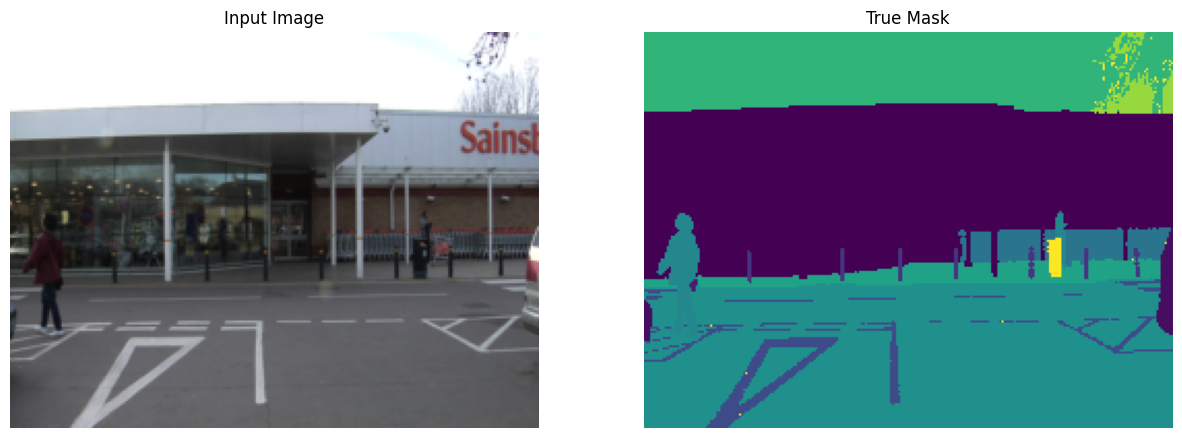

In [29]:
# Get the first batch of data
data_iter = iter(dataloader)
first_batch = next(data_iter)

# Extract the first image and mask
first_image = first_batch['IMAGE'][0]  # First image from the batch
first_mask = first_batch['MASK'][0]    # First mask from the batch

# Display the image and mask
display([first_image, first_mask])

<a name='3-7'></a>
### 3.7 - Loss Function

In semantic segmentation, you need as many masks as you have object classes. In the dataset you're using, each pixel in every mask has been assigned a single integer probability that it belongs to a certain class, from 0 to num_classes-1. The correct class is the layer with the higher probability.

This is different from categorical crossentropy, where the labels should be one-hot encoded (just 0s and 1s). Here, you'll use sparse categorical crossentropy as your loss function, to perform pixel-wise multiclass prediction. Sparse categorical crossentropy is more efficient than other loss functions when you're dealing with lots of classes.

In [30]:
criterion = nn.CrossEntropyLoss()

In [31]:
optimizer = torch.optim.Adam(unet.parameters(), lr=LR, betas=(B1, B2))

<a name='4'></a>
## 4 - Train the Model

In [32]:
losses = []

unet.train()

for epoch in range(EPOCHS):

    epoch_losses = []

    for i, batch in enumerate(dataloader):

        images = batch["IMAGE"].to(device)
        masks = batch["MASK"].to(device)

        # Remove the channel dimension if necessary
        if masks.ndim == 4 and masks.shape[1] == 1:
            masks = masks.squeeze(1)

        optimizer.zero_grad()

        outputs = unet(images)

        loss = criterion(outputs, masks.long())
        loss.backward()

        optimizer.step()

        epoch_losses.append(loss.item())

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Batch {i+1}/{len(dataloader)} | "
            f"Loss: {loss.item():.4f}"
        )

    losses.append(np.mean(epoch_losses))

Epoch 1/50 | Batch 1/47 | Loss: 3.4367
Epoch 1/50 | Batch 2/47 | Loss: 3.4303
Epoch 1/50 | Batch 3/47 | Loss: 3.4085
Epoch 1/50 | Batch 4/47 | Loss: 3.4056
Epoch 1/50 | Batch 5/47 | Loss: 3.3627
Epoch 1/50 | Batch 6/47 | Loss: 3.3221
Epoch 1/50 | Batch 7/47 | Loss: 3.3032
Epoch 1/50 | Batch 8/47 | Loss: 3.3022
Epoch 1/50 | Batch 9/47 | Loss: 3.2585
Epoch 1/50 | Batch 10/47 | Loss: 3.2705
Epoch 1/50 | Batch 11/47 | Loss: 3.1917
Epoch 1/50 | Batch 12/47 | Loss: 3.0498
Epoch 1/50 | Batch 13/47 | Loss: 2.8577
Epoch 1/50 | Batch 14/47 | Loss: 7.5413
Epoch 1/50 | Batch 15/47 | Loss: 2.8550
Epoch 1/50 | Batch 16/47 | Loss: 2.9609
Epoch 1/50 | Batch 17/47 | Loss: 2.9705
Epoch 1/50 | Batch 18/47 | Loss: 2.9740
Epoch 1/50 | Batch 19/47 | Loss: 2.8975
Epoch 1/50 | Batch 20/47 | Loss: 2.9417
Epoch 1/50 | Batch 21/47 | Loss: 2.8982
Epoch 1/50 | Batch 22/47 | Loss: 2.8703
Epoch 1/50 | Batch 23/47 | Loss: 2.7779
Epoch 1/50 | Batch 24/47 | Loss: 2.7806
Epoch 1/50 | Batch 25/47 | Loss: 2.7341
Epoch 1/5

In [33]:
losses

[np.float64(2.8542555646693453),
 np.float64(1.803981659260202),
 np.float64(1.4617188002200836),
 np.float64(1.2658715095925839),
 np.float64(1.2058198515405045),
 np.float64(1.1751266236000872),
 np.float64(1.165854518717908),
 np.float64(1.153529611039669),
 np.float64(1.119131920185495),
 np.float64(1.1005889798732513),
 np.float64(1.0698719354386026),
 np.float64(1.0408437594454338),
 np.float64(1.021953505404452),
 np.float64(1.0040930433476225),
 np.float64(0.9751508324704272),
 np.float64(0.9591461432741043),
 np.float64(0.941479448308336),
 np.float64(0.9546181204471182),
 np.float64(0.9267110900675997),
 np.float64(0.8863119521039597),
 np.float64(0.8645854173822606),
 np.float64(0.8756589255434402),
 np.float64(0.843331811275888),
 np.float64(0.7856474911912958),
 np.float64(0.7421327930815677),
 np.float64(0.7438562512397766),
 np.float64(0.7109895652913033),
 np.float64(0.6852812957256398),
 np.float64(0.6850172725129635),
 np.float64(0.6911478385012201),
 np.float64(0.641

### 4.01 saving the model

In [ ]:
from pathlib import Path

# Create directory
save_root = Path("E:/Study/Deep Learning/4 - Exercises/0 - Source books/3 - Dr. Soleymani/Myself/2 - HW2/Practical/Results")
(save_root / "Models").mkdir(parents=True, exist_ok=True)

checkpoint = {

    # Resume Training
    "epoch": EPOCHS,
    "model_state_dict": unet.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    # Metrics
    "train_loss": losses[-1],


    # Hyperparameters
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "num_classes": len(color_map),

    # Encoder, Decoder
    "encoder_channels": (3,64,128,256,512,1024),
    "decoder_channels": (1024,512,256,128,64),

}

torch.save(
    checkpoint,
    save_root / "Models" / "CamVid_unet_Q2_checkpoint.pth"
)

<a name='4-1'></a>
### 4.1 - Create Predicted Masks

Now, define a function that uses `torch.argmax` in the axis of the number of classes to return the index with the largest value and merge the prediction into a single image:

In [34]:
def create_mask(pred_mask):
    pred_mask = torch.argmax(pred_mask, dim=1)
    return pred_mask

<a name='4-2'></a>
### 4.2 - Plot Model Accuracy

Let's see how your model did!

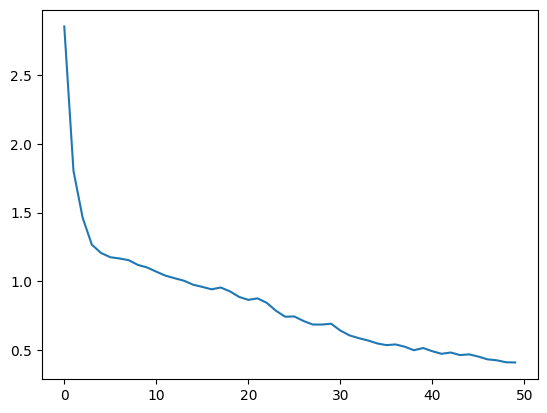

In [35]:
plt.plot(np.arange(len(losses)), losses)

<a name='4-3'></a>
### 4.3 - Show Predictions

Next, check your predicted masks against the true mask and the original input image:

In [36]:
def show_predictions(dataloader, device, num=1):
    """
    Displays the first image of each of the num batches
    """
    for i, batch in enumerate(dataloader):
        IMG = batch["IMAGE"].to(device)
        MASK = batch["MASK"].to(device)

        pred_mask = unet(IMG)
        display([IMG[0].cpu(), MASK[0].cpu(), create_mask(pred_mask)[0].cpu()])

        if i >= num:
            break

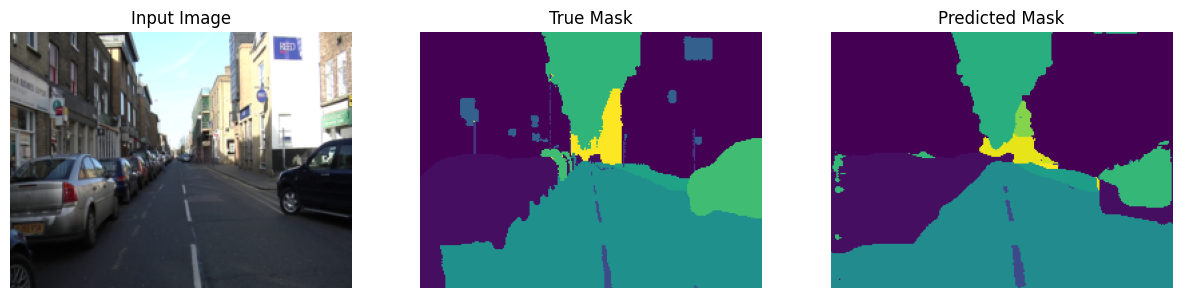

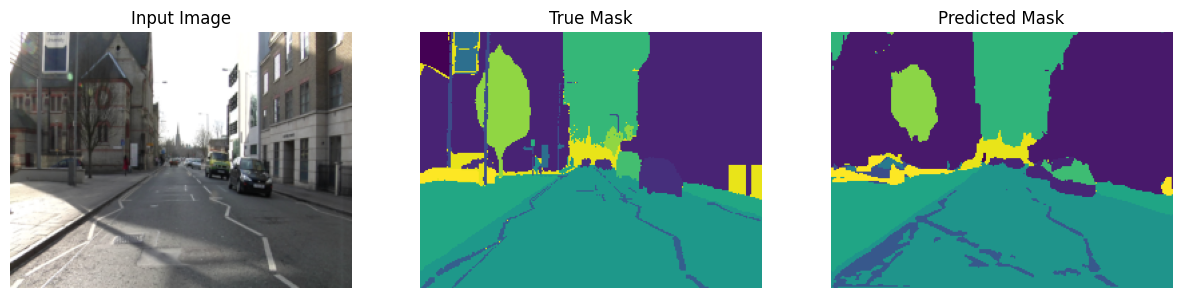

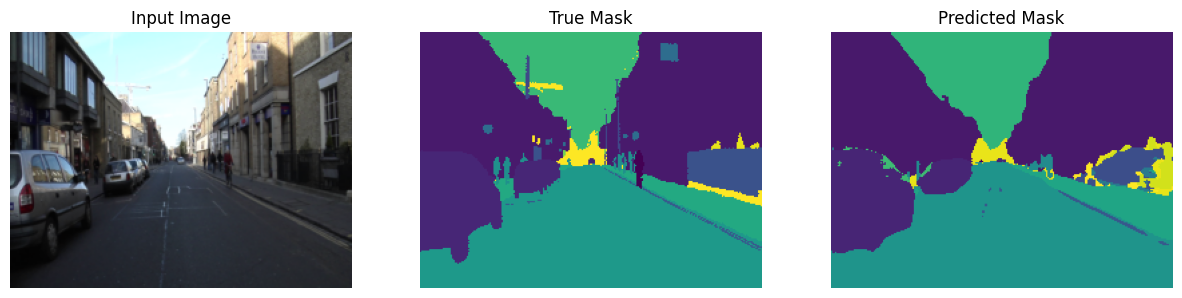

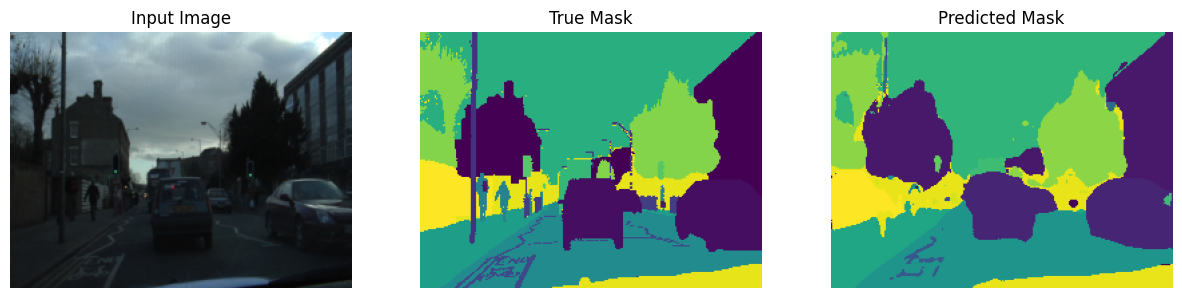

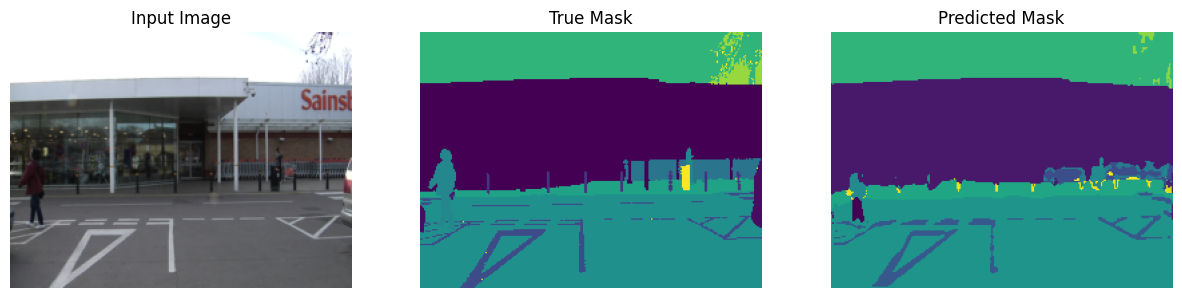

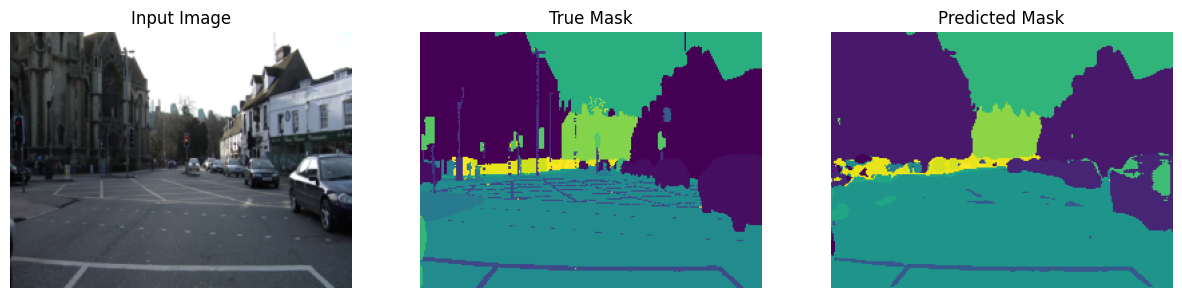

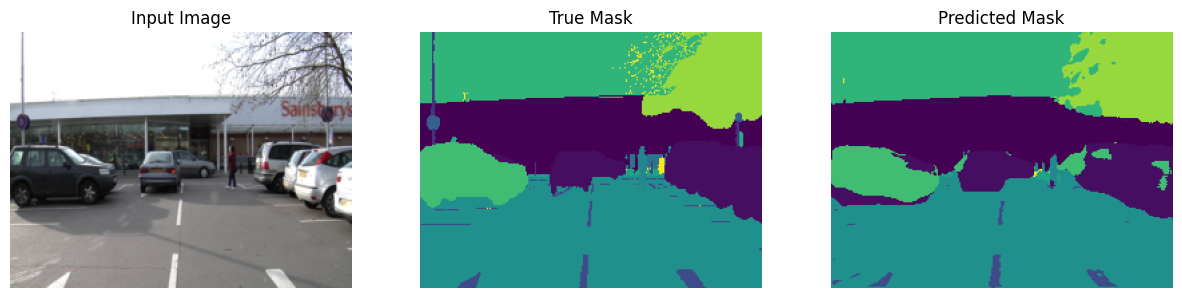

In [37]:
show_predictions(dataloader, device, 6)

<font color='blue'>
    
**What you should remember**:

* Semantic image segmentation predicts a label for every single pixel in an image
* U-Net uses an equal number of convolutional blocks and transposed convolutions for downsampling and upsampling
* Skip connections are used to prevent border pixel information loss and overfitting in U-Net